In [3]:
"""%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install nltk
%pip install re
%pip install emoji
%pip install contractions
%pip install scikit-learn
%pip install collections
%pip install wordcloud
"""

'%pip install numpy\n%pip install pandas\n%pip install matplotlib\n%pip install seaborn\n%pip install nltk\n%pip install re\n%pip install emoji\n%pip install contractions\n%pip install scikit-learn\n%pip install collections\n%pip install wordcloud\n'

In [4]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.probability import FreqDist
import re
import emoji #dealing with emojis
import contractions

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

from collections import Counter
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\xmega\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\xmega\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\xmega\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
a_posts_df = pd.read_csv("a_posts_df.csv")
a_comments_df = pd.read_csv("a_comments_df.csv")

a_posts_df.name = "Ath Posts"
a_comments_df.name = "Ath Comments"


## Exploratory Data Analysis

In [6]:
# head of data set
a_posts_df.head()

,post_id,post_title,post_author,post_score,post_url,post_text,num_comments,created_utc
0,i4agbh,The Satanic Temple just announced a Satanic Ri...,FunnyGeekReference23,100847,https://announcement.thesatanictemple.com/rrr-...,NaN,5213,1.596651e+09
1,vjpvsa,"In honor of today's Supreme Court ruling, I ju...",opequan,91882,https://www.reddit.com/r/atheism/comments/vjpv...,Fuck this oppressive religion that has insiste...,3069,1.656081e+09
2,ua3wb5,Florida atheist petitions to ban the Bible in ...,mepper,88065,https://www.miaminewtimes.com/news/broward-man...,NaN,3506,1.650715e+09
3,gm1j1j,"""Since the Bible says not to charge interest o...",mepper,83764,https://twitter.com/DrPsyBuffy/status/10964212...,NaN,1578,1.589809e+09
4,egd37r,"Teenager, 19, kills 'paedophile priest who abu...",[deleted],78030,https://www.dailymail.co.uk/news/article-78302...,NaN,1737,1.577464e+09


In [7]:
a_posts_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   post_id       300 non-null    str    
 1   post_title    300 non-null    str    
 2   post_author   300 non-null    str    
 3   post_score    300 non-null    int64  
 4   post_url      300 non-null    str    
 5   post_text     64 non-null     str    
 6   num_comments  300 non-null    int64  
 7   created_utc   300 non-null    float64
dtypes: float64(1), int64(2), str(5)
memory usage: 18.9 KB


In [8]:
a_comments_df.head()

,comment_id,post_id,post_title,comment_author,comment_body,comment_score,comment_parent_id,created_utc
0,g0h93fe,i4agbh,The Satanic Temple just announced a Satanic Ri...,[deleted],The Satanic Temple is a critical watchdog on t...,11341,t3_i4agbh,1.596656e+09
1,g0hb3u3,i4agbh,The Satanic Temple just announced a Satanic Ri...,[deleted],“Prior to receiving any anesthetic or sedation...,5024,t3_i4agbh,1.596657e+09
2,g0gyr8l,i4agbh,The Satanic Temple just announced a Satanic Ri...,[deleted],[deleted],4558,t3_i4agbh,1.596651e+09
3,g0gyol4,i4agbh,The Satanic Temple just announced a Satanic Ri...,MissMarlaMoon,"Once again, Satan is the the logical, ethical ...",2651,t3_i4agbh,1.596651e+09
4,g0h66rl,i4agbh,The Satanic Temple just announced a Satanic Ri...,RealUserForSure,"We did it guys, we can officially say to the c...",2331,t3_i4agbh,1.596655e+09


In [9]:
a_comments_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14921 entries, 0 to 14920
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   comment_id         14921 non-null  str    
 1   post_id            14921 non-null  str    
 2   post_title         14921 non-null  str    
 3   comment_author     14921 non-null  str    
 4   comment_body       14920 non-null  str    
 5   comment_score      14921 non-null  int64  
 6   comment_parent_id  14921 non-null  str    
 7   created_utc        14921 non-null  float64
dtypes: float64(1), int64(1), str(6)
memory usage: 932.7 KB


In [10]:
def create_edadf(*dataframes):
    eda_df = []
    for df in dataframes:
        eda_df.append({
            "name": df.name,
            "num_rows": df.shape[0],
            "num_cols": df.shape[1],
            "contains_null": df.isnull().any(axis = None)
        })
    return pd.DataFrame(eda_df)
    
p_eda_df = create_edadf(a_posts_df)
c_eda_df = create_edadf(a_comments_df)

In [11]:
p_eda_df

,name,num_rows,num_cols,contains_null
0,Ath Posts,300,8,True


In [12]:
c_eda_df

,name,num_rows,num_cols,contains_null
0,Ath Comments,14921,8,True


In [13]:
posts_df = a_posts_df.copy()
comments_df = a_comments_df.copy()


## Preprocess text

In [14]:
posts_df["post_string"] = posts_df["post_title"].str.cat(posts_df["post_title"], sep = " ",na_rep = "")
posts_df["post_string"].eq("").sum()

np.int64(0)

In [15]:
def preprocess_df(df, text_col = "post_title"):
    #CLEAN TEXT
    processed_texts = []

    #loading stop words and objects from classes
    default_stopwords = set(stopwords.words('english'))
    default_stopwords.add("edit")
    lmtzr = WordNetLemmatizer()

    def clean_text(sentence):
        #return "" if sentence is NaN so no error occurs
        if not isinstance(sentence, str) or sentence.strip() == "":
            return ""
        
        #convert emojis to text    
        sentence = emoji.demojize(sentence)
        #remove https from strings
        sentence = re.sub(r'http\S+','', sentence) 
        #remove new lines
        sentence = re.sub(r'\\n|:|_',' ', sentence)
        #expand contractions
        sentence = contractions.fix(sentence)
        #remove punctuations and lowercase
        sentence = re.sub(r'[^a-zA-Z0-9\s]', '', sentence).lower()


        #tokenize words
        tokens = word_tokenize(sentence)

        final_words = []
        for word in tokens: #for each word in the sentence
            fixed_word = contractions.fix(word) #expand contractions
            if fixed_word not in default_stopwords:
                lemma = lmtzr.lemmatize(fixed_word) #lemmatize words
                final_words.append(lemma) #append the singular lemmatized word to the final_words list

        return ' '.join(final_words) #append the list of words to processed_text
    
    df[text_col] = df[text_col].apply(clean_text)
    return df

In [16]:
posts_df = preprocess_df(posts_df, text_col = "post_string")

In [17]:
p_string = posts_df["post_string"]
p_string

0      satanic temple announced satanic ritual aborti...
1      honor today supreme court ruling want say fuck...
2      florida atheist petition ban bible school goin...
3      since bible say charge interest loan deut 23 2...
4      teenager 19 kill paedophile priest abused ramm...
                             ...                        
295    trump administration memo homeless shelter exp...
296    unvaccinated catholic student kentucky sue hea...
297    ever noticed atheist seem support transgender ...
298    2020 tweet biden ban prayer public school mean...
299    ted cruz christian first american second imagi...
Name: post_string, Length: 300, dtype: str

# Visualizations

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

class FreqVisualizer:
    words_ = 0
    counts_ = 0

    def __init__(self, df, text_col):
        self.df = df
        self.text_col = text_col
    
    def visualize_word_freq(self):
        vectorizer = CountVectorizer(stop_words='english')
        X_counts = vectorizer.fit_transform(self.df[self.text_col])

        w_counts = X_counts.toarray().sum(axis = 0)
        word_freq = [(word, w_counts[idx])for word, idx in vectorizer.vocabulary_.items()]
        word_freq = sorted(word_freq, key=lambda x: x[1], reverse = True)

        words = [w[0] for w in word_freq[:30]]
        counts = [w[1] for w in word_freq[:30]]
        fig, ax = plt.subplots()
        ax.barh(words, counts, align = "center")
        ax.invert_yaxis()
        plt.show()

    def create_freq_df(self):
        data = {"Words": self.words_, "Counts": self.counts_}
        word_freq_df = pd.DataFrame(data)
        word_freq_df

    def create_wordcloud(self):
        comment_text = ' '.join(word for word in self.df[self.text_col])
        wordcloud = WordCloud(width = 800, height = 400, background_color= "white").generate(comment_text)
        plt.figure()
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.show()

f_vis_pstring = FreqVisualizer(posts_df, "post_string")
f_vis_ptitle = FreqVisualizer(posts_df, "post_title")
f_vis_ptext = FreqVisualizer(posts_df, "post_text")

In [19]:
print(len(posts_df[posts_df["post_text"] != " "]))
print(len(posts_df["post_title"]))
print(p_string.dtype)

300
300
str


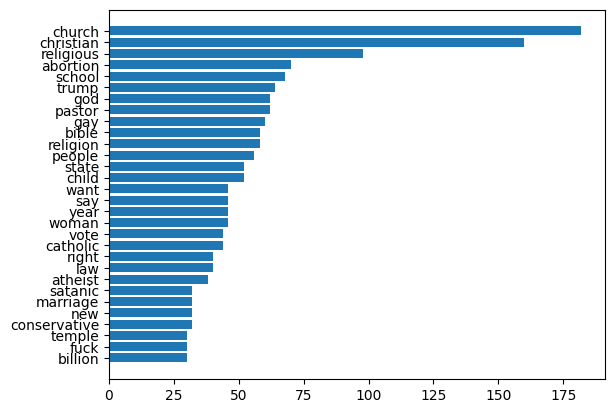

In [20]:
f_vis_pstring.visualize_word_freq()

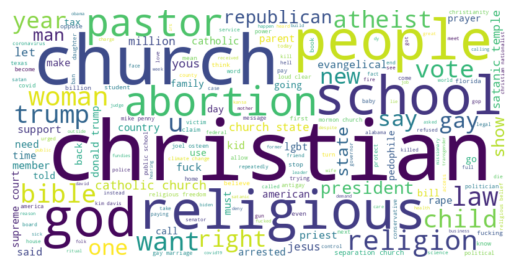

In [21]:
f_vis_pstring.create_wordcloud()

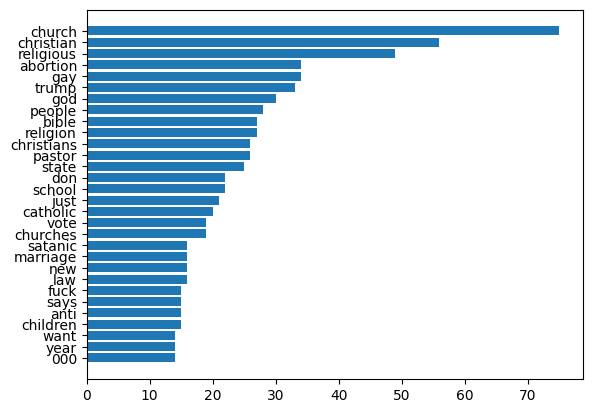

In [22]:
f_vis_ptitle.visualize_word_freq()

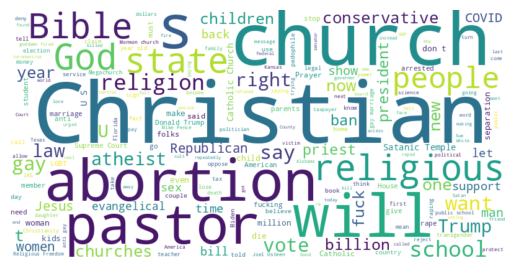

In [23]:
f_vis_ptitle.create_wordcloud()

# Vectorize Text

In [24]:
vectorizer = TfidfVectorizer(lowercase = True, 
                             max_features=100,
                             max_df = 0.9, #remove words occuring more than x% time in document
                             min_df = 5, #remove words occur less than x times in doc
                             ngram_range = (1,3), #look for one word up to trigrams
                             stop_words= "english")
vectors = vectorizer.fit_transform(p_string)

In [25]:
vectors.shape

(300, 100)

In [26]:
vectorizer.vocabulary_

{'satanic': np.int64(71),
 'temple': np.int64(89),
 'abortion': np.int64(0),
 'religious': np.int64(67),
 'freedom': np.int64(27),
 'satanic temple': np.int64(72),
 'supreme': np.int64(84),
 'court': np.int64(19),
 'want': np.int64(96),
 'say': np.int64(73),
 'fuck': np.int64(28),
 'supreme court': np.int64(85),
 'atheist': np.int64(3),
 'ban': np.int64(4),
 'bible': np.int64(6),
 'school': np.int64(74),
 'going': np.int64(32),
 'rape': np.int64(64),
 'student': np.int64(82),
 'use': np.int64(94),
 'make': np.int64(42),
 'republican': np.int64(68),
 'state': np.int64(80),
 'priest': np.int64(62),
 'member': np.int64(47),
 'gay': np.int64(30),
 'marriage': np.int64(44),
 'kid': np.int64(37),
 'separation': np.int64(75),
 'church': np.int64(14),
 'god': np.int64(31),
 'yous': np.int64(99),
 'separation church': np.int64(76),
 'church state': np.int64(15),
 'separation church state': np.int64(77),
 'mormon': np.int64(51),
 'home': np.int64(34),
 'year': np.int64(98),
 'day': np.int64(21),

In [27]:
feature_names = vectorizer.get_feature_names_out()
feature_names


array(['abortion', 'american', 'arrested', 'atheist', 'ban', 'belief',
       'bible', 'biden', 'billion', 'business', 'catholic',
       'catholic church', 'child', 'christian', 'church', 'church state',
       'conservative', 'country', 'couple', 'court', 'covid', 'day',
       'donald', 'donald trump', 'evangelicals', 'family', 'folk',
       'freedom', 'fuck', 'fucking', 'gay', 'god', 'going', 'hate',
       'home', 'house', 'jesus', 'kid', 'law', 'let', 'lgbt', 'like',
       'make', 'man', 'marriage', 'mean', 'megachurch', 'member', 'mike',
       'million', 'money', 'mormon', 'need', 'new', 'oppose', 'parent',
       'pastor', 'pedophile', 'penny', 'people', 'prayer', 'president',
       'priest', 'public', 'rape', 'raping', 'religion', 'religious',
       'republican', 'right', 'said', 'satanic', 'satanic temple', 'say',
       'school', 'separation', 'separation church',
       'separation church state', 'service', 'speech', 'state', 'stop',
       'student', 'support', 'supre

In [28]:
dense = vectors.todense()
denselist = dense.tolist()

all_keywords = []

for description in denselist:
    x = 0
    keywords = []
    for word in description:
        if word > 0:
            keywords.append(feature_names[x])
        x=x+1
    all_keywords.append(keywords)

print(all_keywords) #the relevant words from tf_idf (value is > 0)

[['abortion', 'freedom', 'religious', 'satanic', 'satanic temple', 'temple'], ['court', 'fuck', 'say', 'supreme', 'supreme court', 'want'], ['atheist', 'ban', 'bible', 'going', 'rape', 'school'], ['bible', 'make', 'republican', 'say', 'state', 'student', 'use'], ['priest'], ['gay', 'kid', 'marriage', 'member', 'priest'], ['church', 'church state', 'god', 'separation', 'separation church', 'separation church state', 'state', 'yous'], ['church', 'day', 'family', 'fucking', 'home', 'mormon', 'year'], ['biden', 'christian', 'use', 'woman', 'year'], ['member', 'religious', 'right', 'satanic', 'satanic temple', 'temple'], ['abortion', 'ban', 'let', 'president', 'republican', 'stop', 'told', 'vote'], ['billion', 'business', 'church'], ['bible', 'christian', 'trump'], ['money', 'new'], ['abortion', 'christian', 'fuck', 'jesus', 'law', 'man', 'new', 'rape', 'republican', 'support', 'woman'], ['christian'], ['christian', 'church', 'church state', 'oppose', 'republican', 'say', 'state', 'use'], [

## KMeans Cluster Terms

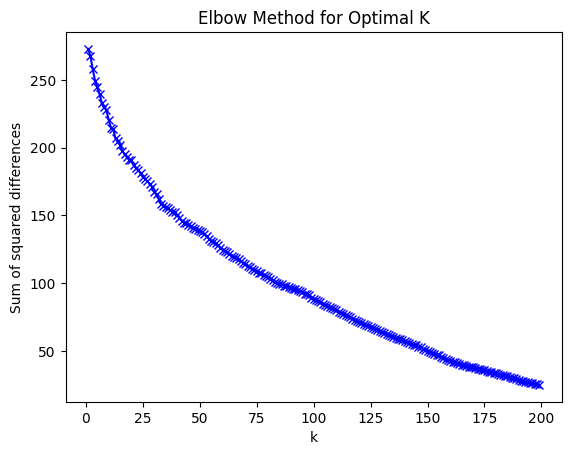

In [29]:
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist

sum_of_squared_distances = []
K = range(1,200)

for k in K:
    km = KMeans(n_clusters= k, max_iter= 200, random_state= 42)
    km = km.fit(vectors)
    sum_of_squared_distances.append(km.inertia_)

plt.plot(K, sum_of_squared_distances, '-bx')
plt.xlabel("k")
plt.ylabel("Sum of squared differences")
plt.title("Elbow Method for Optimal K")
plt.show()


In [30]:
from sklearn.metrics import silhouette_score

k_vals = range(2,10)
silhouette_scores = []

best_k = None
best_silhouette_score = -1

for k in k_vals:
    km = KMeans(n_clusters= k, max_iter= 200, random_state= 42)
    km = km.fit(vectors)

    silhouette_avg = silhouette_score(vectors, km.labels_)
    silhouette_scores.append(silhouette_avg)

    if silhouette_avg > best_silhouette_score:
        best_k = k
        best_silhouette_score = silhouette_avg

print("Best K value:", best_k)
print("Best Silhouette Score:",best_silhouette_score)
    

Best K value: 9
Best Silhouette Score: 0.0625631888879167


In [31]:
true_k = 9
model = KMeans(n_clusters = true_k,
               init = "k-means++",
               max_iter = 100,
               n_init = 1)

x_clustered = model.fit_predict(vectors)


In [32]:
order_centroids = model.cluster_centers_.argsort()[:,::-1]
terms = vectorizer.get_feature_names_out()

In [33]:
cluster_d = {}

for i in range(true_k):
    cluster_i = []
    for ind in order_centroids[i, :10]:
        cluster_i.append(f"{terms[ind]} ")
        cluster_d[f"Cluster {i}"] = cluster_i
    print()


cluster_df = pd.DataFrame(cluster_d)
cluster_df

,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8
0,covid,church,christian,trump,religion,religious,god,tell,woman
1,let,billion,year,donald trump,god,school,yous,money,abortion
2,new,tax,trump,donald,religious,bible,people,god,vote
3,yous,catholic,yous,oppose,parent,pastor,child,pastor,republican
4,vote,child,say,president,american,atheist,country,church,man
5,use,want,bible,satanic,folk,abortion,school,vote,christian
6,trump,catholic church,conservative,christian,freedom,gay,time,trump,rape
7,transgender,pastor,right,evangelicals,christian,say,atheist,use,fuck
8,told,member,atheist,billion,gay,people,day,want,ban
9,time,mormon,state,mike,mean,vote,man,told,new


In [34]:
a_posts_df["cluster"] = x_clustered
a_posts_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   post_id       300 non-null    str    
 1   post_title    300 non-null    str    
 2   post_author   300 non-null    str    
 3   post_score    300 non-null    int64  
 4   post_url      300 non-null    str    
 5   post_text     64 non-null     str    
 6   num_comments  300 non-null    int64  
 7   created_utc   300 non-null    float64
 8   cluster       300 non-null    int32  
dtypes: float64(1), int32(1), int64(2), str(5)
memory usage: 20.1 KB


# BERTopic Modeling

In [ ]:
"""%pip install bertopic
%pip install ipywidgets
%pip install SentenceTransformer
%pip install kneed
%pip install torch
"""

In [37]:
posts_df["post_string"]

0      satanic temple announced satanic ritual aborti...
1      honor today supreme court ruling want say fuck...
2      florida atheist petition ban bible school goin...
3      since bible say charge interest loan deut 23 2...
4      teenager 19 kill paedophile priest abused ramm...
                             ...                        
295    trump administration memo homeless shelter exp...
296    unvaccinated catholic student kentucky sue hea...
297    ever noticed atheist seem support transgender ...
298    2020 tweet biden ban prayer public school mean...
299    ted cruz christian first american second imagi...
Name: post_string, Length: 300, dtype: str

In [91]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
import torch

docs = posts_df["post_string"]
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')
topic_model = BERTopic(embedding_model=sentence_model)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
embedding_model = sentence_model.to(device)
embeddings = embedding_model.encode(docs)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [62]:
embeddings

array([[ 0.00464239,  0.06640499, -0.04218056, ..., -0.03701775,
         0.03686659, -0.01399463],
       [-0.00580477,  0.11575104,  0.04774186, ...,  0.01641151,
         0.09170212,  0.0198801 ],
       [ 0.01259591,  0.02374245,  0.00982349, ..., -0.04030276,
         0.0213927 ,  0.04202543],
       ...,
       [-0.03467513, -0.05806712, -0.05165647, ..., -0.05939175,
         0.10150142,  0.01094461],
       [-0.03018082, -0.00721795,  0.09616809, ..., -0.05669874,
         0.03697315,  0.00503727],
       [ 0.02738591,  0.01541803, -0.01463582, ..., -0.01291717,
        -0.00771595, -0.0444207 ]], shape=(300, 384), dtype=float32)

In [60]:
umap_reducer = UMAP()
reduced_embeddings = umap_reducer.fit_transform(embeddings)
print(f"Reduced: {reduced_embeddings.shape}")

Reduced: (300, 2)


Optimal k: 9


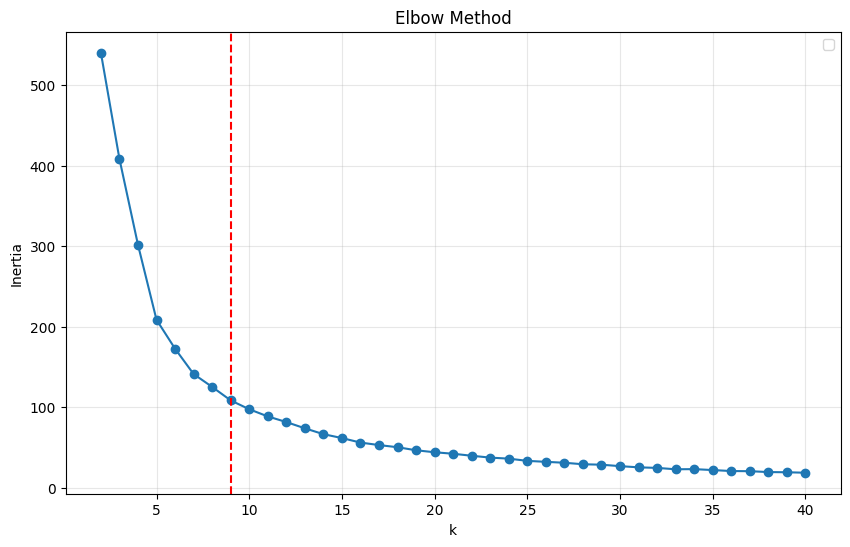

In [ ]:
from kneed import KneeLocator
K_MIN, K_MAX = 2, 40
k_range = range(K_MIN, K_MAX + 1)
ssd = []

for k in k_range:
    km = KMeans(n_clusters = k, n_init = 10, random_state = 42)
    km.fit(reduced_embeddings)
    ssd.append(km.inertia_)

kl = KneeLocator(list(k_range), ssd, curve = "convex", direction = "decreasing")
optimal_k = kl.elbow
print(f"Optimal k: {optimal_k}")

fig, ax = plt.subplots(figsize = (10, 6))
ax.plot(list(k_range), ssd, 'o-')
ax.axvline(x=optimal_k, color = "red", linestyle = "--")
ax.set_xlabel('k'); ax.set_ylabel('Inertia'); ax.set_title('Elbow Method'); ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

Best by silhouette: k=7


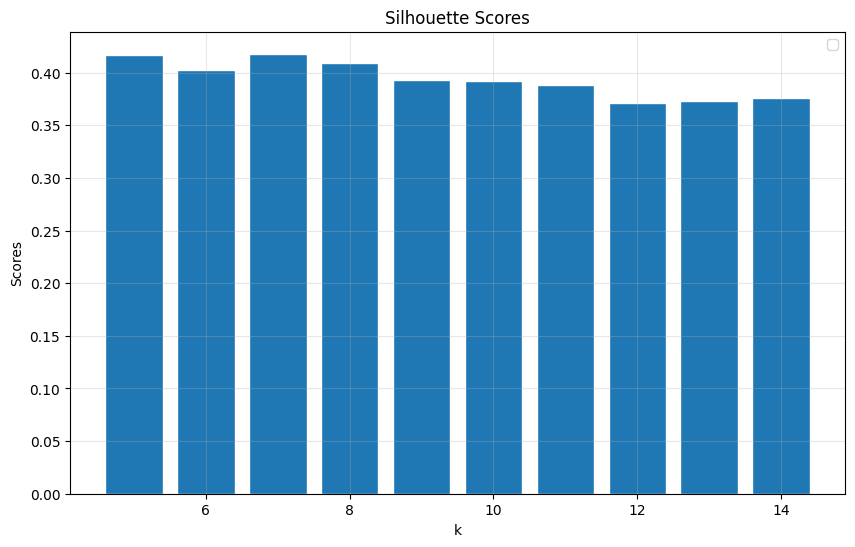

In [82]:
test_range = range(max(2, optimal_k - 4), optimal_k + 6)
sil_scores = []

for k in test_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(reduced_embeddings)
    s = silhouette_score(reduced_embeddings, labels, random_state = 42)
    sil_scores.append(s)

best_k_sil = list(test_range)[np.argmax(sil_scores)]
print(f"Best by silhouette: k={best_k_sil}")

fig, ax = plt.subplots(figsize = (10, 6))
ax.bar(list(test_range), sil_scores, edgecolor = "white")
ax.set_xlabel('k'); ax.set_ylabel('Scores'); ax.set_title('Silhouette Scores'); ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

In [116]:
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import KeyBERTInspired
from bertopic.representation import MaximalMarginalRelevance

K_A = optimal_k
K_B = best_k_sil
k_values = sorted(set([K_A, K_B]))
k_values = [int(k) for k in k_values]

vectorizer_model = CountVectorizer(min_df = 5, ngram_range=(1,2), stop_words = "english")
representation_model = KeyBERTInspired()
representation_model = MaximalMarginalRelevance(diversity = 0.3)

k_values

[7, 9]

In [ ]:
#delete later?
for k in k_values:
    print(f"BERTopic k = {k}...")
    

In [117]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_reducer,
    hdbscan_model=KMeans(n_clusters = K_A, n_init=10, random_state=42),
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    verbose=True
)

t,p = topic_model.fit_transform(docs, embeddings=embeddings)
topic_model.get_topic_info()


2026-03-17 15:47:40,103 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-17 15:47:40,352 - BERTopic - Dimensionality - Completed ✓
2026-03-17 15:47:40,354 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-17 15:47:40,426 - BERTopic - Cluster - Completed ✓
2026-03-17 15:47:40,428 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-17 15:47:40,809 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,0,45,0_bible_school_law_republican,"[bible, school, law, republican, abortion, ban...",[texas ag sued keep bible quote school trouble...
1,1,42,1_church_pastor_trump_marriage,"[church, pastor, trump, marriage, vote, church...",[joel osteen church cash discovery renews call...
2,2,38,2_pastor_church_abortion_kid,"[pastor, church, abortion, kid, say, bible, fl...",[let u take moment appreciate fucked gay work ...
3,3,35,3_vote_religion_biden_church state,"[vote, religion, biden, church state, state, c...",[serious want look project 2025 heard already ...
4,4,32,4_christian_say_prayer_religion,"[christian, say, prayer, religion, stop, state...",[tim walz say sick tired hearing thought praye...
5,5,29,5_pastor_church_prayer_christian,"[pastor, church, prayer, christian, turn, spee...",[pastor greg locke shut church service social ...
6,6,29,6_marriage_supreme court_christian_bible,"[marriage, supreme court, christian, bible, ba...",[christian employer taking case supreme court ...
7,7,27,7_trump_christian_kid_support,"[trump, christian, kid, support, atheist, sata...",[fucking scary paula white trump spiritual adv...
8,8,23,8_religious_abortion_say_satan,"[religious, abortion, say, satan, deny, speech...",[satanic temple plan use federal religious fre...


In [118]:
topic_model.get_representative_docs(0)

['texas ag sued keep bible quote school troubled muslim prayer republican give damn freedom religion give damn religious protection religion texas ag sued keep bible quote school troubled muslim prayer republican give damn freedom religion give damn religious protection religion',
 'west virginia family get bible class removed public school bullied christian family deserves lot credit willingness right even christian around pile hate west virginia family get bible class removed public school bullied christian family deserves lot credit willingness right even christian around pile hate',
 'bible removed texas school district due state law banning sexually explicit content bible removed texas school district due state law banning sexually explicit content']

In [121]:
topic_model.visualize_topics()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'customdata': array([[0, 'bible | school | law | republican | abortion', 45],
                                   [1, 'church | pastor | trump | marriage | vote', 42],
                                   [2, 'pastor | church | abortion | kid | say', 38],
                                   [3, 'vote | religion | biden | church state | state', 35],
                                   [4, 'christian | say | prayer | religion | stop', 32],
                                   [5, 'pastor | church | prayer | christian | turn', 29],
                                   [6, 'marriage | supreme court | christian | bible | ban', 29],
                                   [7, 'trump | christian | kid | support | atheist', 27],
                                   [8, 'religious | abortion | say | satan | deny', 23]], dtype=object),
              'hovertemplate': '<b>Topic %{customdata[0]}</b><br>%{customdata[1]}<br>Size: %{customdata[2]}',
              'legendgroup': '',
              'marker': {'color': '#B0BEC5',
                         'line': {'color': 'DarkSlateGrey', 'width': 2},
                         'size': {'bdata': 'LSomIyAdHRsX', 'dtype': 'i1'},
                         'sizemode': 'area',
                         'sizeref': 0.028125,
                         'symbol': 'circle'},
              'mode': 'markers',
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'type': 'scatter',
              'x': {'bdata': 'vNaKwPJ7PsBlOY/AJ7CIwATchcCtjGDAa2miwMz8WMAFM63A', 'dtype': 'f4'},
              'xaxis': 'x',
              'y': {'bdata': 'BsgvQfYFYkHxHjdBTfxbQRseY0FGSGZBJ30wQVJmT0Gc1UJB', 'dtype': 'f4'},
              'yaxis': 'y'}],
    'layout': {'annotations': [{'showarrow': False,
                                'text': 'D1',
                                'x': np.float32(-6.2243495),
                                'y': np.float32(12.944963),
                                'yshift': 10},
                               {'showarrow': False,
                                'text': 'D2',
                                'x': np.float32(-4.3771086),
                                'xshift': 10,
                                'y': np.float32(16.551542)}],
               'height': 650,
               'hoverlabel': {'bgcolor': 'white', 'font': {'family': 'Rockwell', 'size': 16}},
               'legend': {'itemsizing': 'constant', 'tracegroupgap': 0},
               'margin': {'t': 60},
               'shapes': [{'line': {'color': '#CFD8DC', 'width': 2},
                           'type': 'line',
                           'x0': np.float32(-4.3771086),
                           'x1': np.float32(-4.3771086),
                           'y0': np.float32(9.338384),
                           'y1': np.float32(16.551542)},
                          {'line': {'color': '#9E9E9E', 'width': 2},
                           'type': 'line',
                           'x0': np.float32(-6.2243495),
                           'x1': np.float32(-2.5298676),
                           'y0': np.float32(12.944963),
                           'y1': np.float32(12.944963)}],
               'sliders': [{'active': 0,
                            'pad': {'t': 50},
                            'steps': [{'args': [{'marker.color': [['red',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5',
                                                                  '#B0BEC5']]}],
                                       'lab

In [122]:
posts_df_k = posts_df.copy()
posts_df_k['topic'] = t
posts_df_k.head()

,post_id,post_title,post_author,post_score,post_url,post_text,num_comments,created_utc,post_string,topic
0,i4agbh,The Satanic Temple just announced a Satanic Ri...,FunnyGeekReference23,100847,https://announcement.thesatanictemple.com/rrr-...,NaN,5213,1.596651e+09,satanic temple announced satanic ritual aborti...,8
1,vjpvsa,"In honor of today's Supreme Court ruling, I ju...",opequan,91882,https://www.reddit.com/r/atheism/comments/vjpv...,Fuck this oppressive religion that has insiste...,3069,1.656081e+09,honor today supreme court ruling want say fuck...,2
2,ua3wb5,Florida atheist petitions to ban the Bible in ...,mepper,88065,https://www.miaminewtimes.com/news/broward-man...,NaN,3506,1.650715e+09,florida atheist petition ban bible school goin...,0
3,gm1j1j,"""Since the Bible says not to charge interest o...",mepper,83764,https://twitter.com/DrPsyBuffy/status/10964212...,NaN,1578,1.589809e+09,since bible say charge interest loan deut 23 2...,0
4,egd37r,"Teenager, 19, kills 'paedophile priest who abu...",[deleted],78030,https://www.dailymail.co.uk/news/article-78302...,NaN,1737,1.577464e+09,teenager 19 kill paedophile priest abused ramm...,2


# LDA Topic Modeling

In [41]:
#https://github.com/keitazoumana/lda-tutorial/blob/main/topic-modeling-with-lda.ipynb
from sklearn.decomposition import LatentDirichletAllocation

In [42]:
p_title = posts_df["post_string"]
#turning text into bag of words
vectorizer = CountVectorizer(max_df = 0.95, min_df = 3, stop_words="english")
dtm = vectorizer.fit_transform(posts_df["post_string"])
dtm #document term matrix has 300 documents

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2441 stored elements and shape (300, 392)>

In [43]:
k_vals = range(2, 11)
silhouette_scores = []

best_k = None
best_silhouette_score = -1

for k in k_vals:
    lda_model = LatentDirichletAllocation(n_components=k, max_iter = 30, random_state = 42)
    topic_dist = lda_model.fit_transform(vectors)

    labels = np.argmax(topic_dist, axis = 1)

    silhouette_avg = silhouette_score(vectors, labels)
    silhouette_scores.append(silhouette_avg)

    if silhouette_avg > best_silhouette_score:
        best_k = k
        best_silhouette_score = silhouette_avg

print("Best K value:", best_k)
print("Best Silhouette Score:",best_silhouette_score)

Best K value: 2
Best Silhouette Score: 0.02169323868559133


In [44]:
n_topics = 2
LDA_model = LatentDirichletAllocation(n_components= n_topics,
                                      max_iter=30,
                                      random_state = 42)

LDA_model.fit(dtm)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",2
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",30
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [45]:
import random
for i in range(15):
    random_word_ID = random.randint(0,300)
    print(vectorizer.get_feature_names_out()[random_word_ID])


parent
pay
hearing
removed
clear
donald
home
covid
hospital
imagine
family
atheist
billion
meant
know


In [46]:
a_topic = LDA_model.components_[0] #get first topic from 7 topics that we set in NB_TOPICS

In [47]:
top_10_word_indices = a_topic.argsort()[-10:] #get top 10 words for the first topic

for i in top_10_word_indices:
    print(vectorizer.get_feature_names_out()[i])

religion
year
bible
people
christian
woman
pastor
abortion
religious
church


In [48]:
for i, topic in enumerate(LDA_model.components_):
    print("Top {} words for topic #{}".format(10,i))
    print([vectorizer.get_feature_names_out()[index] for index in topic.argsort()[-10:]])
    print("\n")

Top 10 words for topic #0
['religion', 'year', 'bible', 'people', 'christian', 'woman', 'pastor', 'abortion', 'religious', 'church']


Top 10 words for topic #1
['atheist', 'want', 'marriage', 'child', 'gay', 'vote', 'school', 'god', 'trump', 'christian']




In [49]:
final_topics = LDA_model.transform(dtm)
final_topics.shape

(300, 2)

In [50]:
posts_labeled = posts_df.copy()
posts_labeled["Topic"] = final_topics.argmax(axis = 1)
posts_labeled.head() 

,post_id,post_title,post_author,post_score,post_url,post_text,num_comments,created_utc,post_string,Topic
0,i4agbh,The Satanic Temple just announced a Satanic Ri...,FunnyGeekReference23,100847,https://announcement.thesatanictemple.com/rrr-...,NaN,5213,1.596651e+09,satanic temple announced satanic ritual aborti...,0
1,vjpvsa,"In honor of today's Supreme Court ruling, I ju...",opequan,91882,https://www.reddit.com/r/atheism/comments/vjpv...,Fuck this oppressive religion that has insiste...,3069,1.656081e+09,honor today supreme court ruling want say fuck...,1
2,ua3wb5,Florida atheist petitions to ban the Bible in ...,mepper,88065,https://www.miaminewtimes.com/news/broward-man...,NaN,3506,1.650715e+09,florida atheist petition ban bible school goin...,0
3,gm1j1j,"""Since the Bible says not to charge interest o...",mepper,83764,https://twitter.com/DrPsyBuffy/status/10964212...,NaN,1578,1.589809e+09,since bible say charge interest loan deut 23 2...,0
4,egd37r,"Teenager, 19, kills 'paedophile priest who abu...",[deleted],78030,https://www.dailymail.co.uk/news/article-78302...,NaN,1737,1.577464e+09,teenager 19 kill paedophile priest abused ramm...,1


(array([155.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 145.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

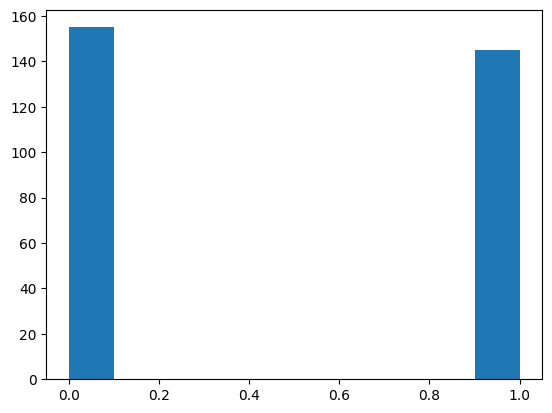

In [51]:
plt.hist(posts_labeled["Topic"])

# Sentiment score (Hugging Face)

In [123]:
%pip install -q transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [124]:
from transformers import pipeline
sentiment_pipeline = pipeline("sentiment-analysis")
data = ["I love you", "I HATE YOU!!!"]
sentiment_pipeline(data)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9998656511306763},
 {'label': 'NEGATIVE', 'score': 0.9973791837692261}]

## Label sentiment score for comments (VADER Sentiment)

In [52]:
def preprocess_comment(df, text_col = "comment_body"):
    #CLEAN TEXT
    processed_texts = []
    lmtzr = WordNetLemmatizer()

    def clean_text(sentence):
        #return "" if sentence is NaN so no error occurs
        if not isinstance(sentence, str) or sentence.strip() == "":
            return ""
        
        #convert emojis to text    
        sentence = emoji.demojize(sentence)
        #remove https from strings
        sentence = re.sub(r'http\S+','', sentence) 
        #remove new lines
        sentence = re.sub(r'\\n|:|_',' ', sentence)
        #expand contractions
        sentence = contractions.fix(sentence)
        #remove punctuations and lowercase
        sentence = re.sub(r'[^a-zA-Z0-9\s]', '', sentence).lower()
        return(sentence)

        #tokenize words
        """
        tokens = word_tokenize(sentence)

        final_words = []
        for word in tokens: #for each word in the sentence
            fixed_word = contractions.fix(word) #expand contractions
            lemma = lmtzr.lemmatize(fixed_word) #lemmatize words
            final_words.append(lemma) #append the singular lemmatized word to the final_words list

        return ' '.join(final_words) #append the list of words to processed_text
        """
    
    df[text_col] = df[text_col].apply(clean_text)
    return df

In [53]:
comments_test = preprocess_comment(comments_df, text_col = "comment_body")
comments_test["comment_body"]

0        the satanic temple is a critical watchdog on t...
1        prior to receiving any anesthetic or sedation ...
2                                                  deleted
3        once again satan is the the logical ethical ch...
4        we did it guys we can officially say to the co...
                               ...                        
14916    ted cruz is a major idiot if you have the inte...
14917    lol these people are such a joke\n\ncannot bel...
14918    no ted your an asshole first and your an aardv...
14919    did not kennedy have to reasure the public tha...
14920                the pandering is strong with this one
Name: comment_body, Length: 14921, dtype: str

In [54]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
def score_sentiment(sentence):
    sid_obj = SentimentIntensityAnalyzer()
    sentiment_dict = sid_obj.polarity_scores(sentence)

    


ModuleNotFoundError: No module named 'vaderSentiment'

In [ ]:
sid_obj = SentimentIntensityAnalyzer()
comments_test['compound'] = [sid_obj.polarity_scores(x)['compound'] for x in comments_test["comment_body"]]

In [ ]:
def extract_score(compound):
    score = sid_obj.polarity_scores(text)
    compound = score['compound']

    sentiment = 'neutral'
    if(compound >= 0.05):
        sentiment = "positive"
    elif(compound <= -0.05):
        sentiment = "negative"

    return sentiment

means = comments_test.groupby('post_id')['compound'].mean()
comments_test["c_means"] = comments_test['post_id'].map(means)
comments_test["sentiment"] = comments_test['c_means'].apply(lambda x: "positive" if x >= 0.05  else ("negative" if x<= -0.05 else "neutral"))

In [ ]:
comments_test.describe()

,comment_score,created_utc,compound,c_means
count,14921.000000,1.492100e+04,14921.000000,14921.000000
mean,178.803096,1.590469e+09,-0.014767,-0.014767
std,701.067544,6.340631e+07,0.525287,0.140516
min,-152.000000,1.441415e+09,-0.999900,-0.351988
25%,5.000000,1.552748e+09,-0.459500,-0.118174
50%,11.000000,1.589124e+09,0.000000,-0.008462
75%,43.000000,1.624372e+09,0.407100,0.076114
max,23599.000000,1.749963e+09,0.999700,0.342458


In [ ]:
comments_test.to_csv("comment_compound_sent.csv", index = False)

## Prepare for ML

In [ ]:
comments_test.drop_duplicates(subset=["post_id"])
len(comments_test)

14921

In [ ]:
cols_to_keep = ["post_id", "c_means"]
a_posts_lab = a_posts_df.merge(
    comments_test[cols_to_keep], 
    on = "post_id",
    how="left")

In [ ]:
a_posts_lab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14921 entries, 0 to 14920
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   post_id       14921 non-null  object 
 1   post_title    14921 non-null  object 
 2   post_author   14921 non-null  object 
 3   post_score    14921 non-null  int64  
 4   post_url      14921 non-null  object 
 5   post_text     3143 non-null   object 
 6   num_comments  14921 non-null  int64  
 7   created_utc   14921 non-null  float64
 8   cluster       14921 non-null  int32  
 9   c_means       14921 non-null  float64
dtypes: float64(2), int32(1), int64(2), object(5)
memory usage: 1.1+ MB


In [ ]:
#split data to test and train
from sklearn.model_selection import train_test_split
train_p, test_p = train_test_split(a_posts_lab, test_size = 0.2, random_state=42)

In [ ]:
#filter a_comments_df into train and test based on train_p and test_p
#train_c = a_comments_df.loc[a_comments_df["post_id"].isin(train_p["post_id"])]
#test_c = a_comments_df.loc[a_comments_df["post_id"].isin(test_p["post_id"])]

In [ ]:
#check to see if total equals original length
#print(len(train_c) + len(test_c))
print(len(train_p) + len(test_p))
posts = train_p.copy()
#comments = train_c.copy()

14921


In [ ]:
train_prepared = train_p.drop(["c_means","post_id","post_title","post_author","post_url","post_text"], axis = 1)
train_labelled = train_p["c_means"].copy()

train_prepared.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11936 entries, 510 to 7270
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   post_score    11936 non-null  int64  
 1   num_comments  11936 non-null  int64  
 2   created_utc   11936 non-null  float64
 3   cluster       11936 non-null  int32  
dtypes: float64(1), int32(1), int64(2)
memory usage: 419.6 KB


In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(train_prepared, train_labelled)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
some_data = train_prepared.iloc[:10]
some_labels = train_labelled.iloc[:10]
print("Prediction:", lin_reg.predict(some_data))
print("labels:", list(some_labels))

Prediction: [-0.066506   -0.00761676  0.02566946  0.00065049 -0.02836346 -0.01118523
  0.03101614 -0.03954294  0.01589216 -0.03595726]
labels: [-0.19453800000000002, -0.28159, 0.12515, 0.028962, -0.07803600000000001, -0.05458799999999999, 0.058150000000000014, 0.141498, 0.032514, 0.113452]


In [ ]:
from sklearn.metrics import mean_squared_error
predictions = lin_reg.predict(train_prepared)
lin_mse = mean_squared_error(train_labelled, predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(0.1384236437073969)

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(train_prepared, train_labelled)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [ ]:
some_data = train_prepared.iloc[:10]
some_labels = train_labelled.iloc[:10]
print("Prediction:", tree_reg.predict(some_data))
print("labels:", list(some_labels))

Prediction: [-0.194538 -0.28159   0.12515   0.028962 -0.078036 -0.054588  0.05815
  0.141498  0.032514  0.113452]
labels: [-0.19453800000000002, -0.28159, 0.12515, 0.028962, -0.07803600000000001, -0.05458799999999999, 0.058150000000000014, 0.141498, 0.032514, 0.113452]


In [ ]:
predictions = tree_reg.predict(train_prepared)
lin_mse = mean_squared_error(train_labelled, predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(8.253809489248733e-17)

# Cross-Validation

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_reg, train_prepared, train_labelled, scoring = "neg_mean_squared_error", cv = 10)
tree_rmse_scores = np.sqrt(-scores)

In [ ]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard Deviation:", scores.std())

display_scores(tree_rmse_scores)

Scores: [7.26317874e-17 7.00829109e-17 7.01705452e-17 6.84945273e-17
 7.32680068e-17 7.25487953e-17 6.83808859e-17 7.11537940e-17
 6.84553384e-17 7.11970471e-17]
Mean: 7.063836382515447e-17
Standard Deviation: 1.7349791769467086e-18


In [ ]:
lin_scores = cross_val_score(lin_reg, train_prepared, train_labelled, scoring = "neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [0.14019635 0.14110101 0.1393036  0.13686361 0.13545287 0.13979135
 0.13897333 0.13666316 0.13792362 0.13848974]
Mean: 0.13847586370682613
Standard Deviation: 0.001668635971702722


In [ ]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor()
forest_reg.fit(train_prepared, train_labelled)
forest_scores = cross_val_score(forest_reg, train_prepared, train_labelled, scoring = "neg_mean_squared_error", cv=10)
forest_rmse = np.sqrt(-forest_scores)
display_scores(forest_rmse)

Scores: [2.04496198e-16 2.10878115e-16 2.02209519e-16 2.00149401e-16
 2.02388781e-16 2.03148553e-16 2.03747007e-16 1.97121975e-16
 2.06511145e-16 1.92936797e-16]
Mean: 2.023587490314986e-16
Standard Deviation: 4.669508606369139e-18


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators': [3,10,30], 'max_features': [2,4,6,8]},
    {'bootstrap': [False], 'n_estimators': [3,10], 'max_features': [2,3,4]}
]

grid_search = GridSearchCV(forest_reg, param_grid, cv =5, scoring="neg_mean_squared_error",return_train_score=True)
grid_search.fit(train_prepared, train_labelled)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation t